<a href="https://colab.research.google.com/github/ehdrb1023/GraduationProject/blob/main/SWA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. 구글 드라이브 연동 (실행 후 링크나 팝업창에서 권한 허용 눌러줘!)
from google.colab import drive
import os
import urllib.request

drive.mount('/content/drive')

# 2. 구글 드라이브 내에 졸업프로젝트 전용 데이터 폴더 생성
drive_data_path = '/content/drive/MyDrive/Colab_Data'
os.makedirs(drive_data_path, exist_ok=True)

# 3. CIFAR-10 압축본 다운로드 URL 지정 (fast.ai의 초고속 미러 서버)
cifar_url = 'https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz'
destination_path = os.path.join(drive_data_path, 'cifar10.tgz')

# 4. 다운로드 시작
if not os.path.exists(destination_path):
    print("🚀 구글 드라이브로 CIFAR-10 압축 파일 다운로드를 시작합니다...")
    print("대략 10초~20초 정도 소요됩니다. 잠시만 기다려주세요.")

    urllib.request.urlretrieve(cifar_url, destination_path)

    print("\n✅ 다운로드 완료!")
    print(f"파일 저장 위치: {destination_path}")
    print(f"현재 파일 크기: {os.path.getsize(destination_path) / (1024*1024):.2f} MB")
else:
    print("✨ 이미 구글 드라이브에 cifar10.tgz 파일이 안전하게 존재합니다!")

Mounted at /content/drive
✨ 이미 구글 드라이브에 cifar10.tgz 파일이 안전하게 존재합니다!


In [ ]:
import os
import time
import tarfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 현재 사용 중인 장치: {device}\n")

# ==========================================
# 1. 초고속 데이터 압축 해제 (Drive -> Colab Local)
# ==========================================
drive_zip_path = '/content/drive/MyDrive/Colab_Data/cifar10.tgz'
local_extract_path = '/content/'
local_data_path = '/content/cifar10'  # fast.ai 압축을 풀면 나오는 기본 폴더명

if not os.path.exists(local_data_path):
    print("📦 구글 드라이브에서 코랩 로컬로 데이터를 푸는 중... (약 10~15초 소요)")
    with tarfile.open(drive_zip_path, 'r:gz') as tar:
        tar.extractall(path=local_extract_path)
    print("✅ 로컬 압축 해제 완료!\n")
else:
    print("✨ 이미 코랩 로컬에 데이터가 압축 해제되어 있습니다.\n")

# ==========================================
# 2. 데이터셋 및 데이터로더 설정 (Data Augmentation)
# ==========================================
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'train'), transform=transform_train)
test_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'test'), transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

print(f"📊 학습 데이터: {len(train_dataset)}장 | 테스트 데이터: {len(test_dataset)}장 준비 완료\n")

🖥️ 현재 사용 중인 장치: cuda

📦 구글 드라이브에서 코랩 로컬로 데이터를 푸는 중... (약 10~15초 소요)


/tmp/ipykernel_549/2377517764.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=local_extract_path)


✅ 로컬 압축 해제 완료!

📊 학습 데이터: 50000장 | 테스트 데이터: 10000장 준비 완료



In [ ]:
# ==========================================
# 3. 모델 정의 (ResNet-18 for CIFAR-10)
# ==========================================
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

print("✅ ResNet-18 모델 로드 및 CIFAR-10 커스텀 완료!\n")

✅ ResNet-18 모델 로드 및 CIFAR-10 커스텀 완료!



In [ ]:
# ==========================================
# 4. Sharpness 측정 함수 (SAM 스타일: L(w+eps) - L(w))
# ==========================================
def measure_sharpness(model_to_probe, criterion, data_loader, device, rho=0.05, n_batches=5):
    """여러 배치 평균으로 노이즈를 완화한 sharpness 측정.
    값이 클수록 뾰족한(sharp) minima, 작을수록 평평한(flat) minima."""
    model_to_probe.eval()
    diffs = []
    it = iter(data_loader)
    for _ in range(n_batches):
        try:
            inputs, targets = next(it)
        except StopIteration:
            it = iter(data_loader)
            inputs, targets = next(it)
        inputs, targets = inputs.to(device), targets.to(device)

        with torch.no_grad():
            loss_w = criterion(model_to_probe(inputs), targets).item()

        model_to_probe.zero_grad()
        loss = criterion(model_to_probe(inputs), targets)
        loss.backward()

        grad_norm = torch.norm(torch.stack([
            p.grad.norm(p=2) for p in model_to_probe.parameters() if p.grad is not None
        ]), p=2)
        scale = rho / (grad_norm + 1e-12)

        e_ws = []
        with torch.no_grad():
            for p in model_to_probe.parameters():
                if p.grad is None:
                    continue
                e_w = p.grad * scale
                p.add_(e_w)
                e_ws.append((p, e_w))

        with torch.no_grad():
            loss_w_eps = criterion(model_to_probe(inputs), targets).item()
            for p, e_w in e_ws:
                p.sub_(e_w)

        model_to_probe.zero_grad()
        diffs.append(loss_w_eps - loss_w)

    model_to_probe.train()
    return sum(diffs) / len(diffs)

print("✅ Sharpness 측정 함수 정의 완료!\n")

✅ Sharpness 측정 함수 정의 완료!



In [ ]:
# ==========================================
# 5. SWA 학습 루프 (히스토리 기록 포함)
# ==========================================
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

def evaluate(model_to_eval, loader):
    model_to_eval.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model_to_eval(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100. * correct / total

criterion = nn.CrossEntropyLoss()
epochs = 50
swa_start = 30          # 이 에폭부터 SWA 구간 시작 (전체 50 에폭 중 마지막 20 에폭)
base_lr = 0.1
swa_lr = 0.05

optimizer = optim.SGD(model.parameters(), lr=base_lr, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=swa_start)

swa_model = AveragedModel(model)
swa_scheduler = SWALR(optimizer, swa_lr=swa_lr, anneal_epochs=5, anneal_strategy='cos')

# 플롯을 위한 히스토리 기록용 딕셔너리
history = {'epoch': [], 'phase': [], 'train_loss': [], 'test_acc_raw': [], 'lr': []}

print(f"🚀 CIFAR-10 학습 시작 (SWA, swa_start={swa_start}/{epochs})...\n")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    start_time = time.time()

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    if epoch >= swa_start:
        swa_model.update_parameters(model)
        swa_scheduler.step()
        phase_tag = "SWA-collect"
    else:
        scheduler.step()
        phase_tag = "SGD-warmup"

    epoch_time = time.time() - start_time
    train_loss = running_loss / len(train_loader)
    test_acc = evaluate(model, test_loader)
    cur_lr = optimizer.param_groups[0]['lr']

    history['epoch'].append(epoch + 1)
    history['phase'].append(phase_tag)
    history['train_loss'].append(train_loss)
    history['test_acc_raw'].append(test_acc)
    history['lr'].append(cur_lr)

    print(f"[{phase_tag}] Epoch [{epoch+1}/{epochs}] | Time: {epoch_time:.1f}s | "
          f"Train Loss: {train_loss:.4f} | Test Acc(SGD model): {test_acc:.2f}% | LR: {cur_lr:.5f}")

print("\n🔧 SWA 평균 모델의 BatchNorm 통계 재계산 중...")
update_bn(train_loader, swa_model, device=device)

swa_test_acc = evaluate(swa_model, test_loader)
final_sgd_acc = evaluate(model, test_loader)

print("\n📐 Sharpness 측정 중 (SGD 단독 vs SWA 평균)...")
sharpness_sgd = measure_sharpness(model, criterion, train_loader, device, rho=0.05, n_batches=5)
sharpness_swa = measure_sharpness(swa_model, criterion, train_loader, device, rho=0.05, n_batches=5)

print(f"\n🎉 SWA 학습 종료!")
print(f"   - 최종 SGD 단독 모델 Test Acc : {final_sgd_acc:.2f}% | Sharpness: {sharpness_sgd:.4f}")
print(f"   - SWA 평균 모델 Test Acc      : {swa_test_acc:.2f}% | Sharpness: {sharpness_swa:.4f}")

🚀 CIFAR-10 학습 시작 (SWA, swa_start=30/50)...

[SGD-warmup] Epoch [1/50] | Time: 32.6s | Train Loss: 2.0478 | Test Acc(SGD model): 43.90% | LR: 0.09973
[SGD-warmup] Epoch [2/50] | Time: 29.2s | Train Loss: 1.4588 | Test Acc(SGD model): 50.12% | LR: 0.09891
[SGD-warmup] Epoch [3/50] | Time: 29.0s | Train Loss: 1.2682 | Test Acc(SGD model): 59.60% | LR: 0.09755
[SGD-warmup] Epoch [4/50] | Time: 29.7s | Train Loss: 1.1228 | Test Acc(SGD model): 62.58% | LR: 0.09568
[SGD-warmup] Epoch [5/50] | Time: 30.0s | Train Loss: 1.0278 | Test Acc(SGD model): 57.69% | LR: 0.09330
[SGD-warmup] Epoch [6/50] | Time: 30.1s | Train Loss: 0.9671 | Test Acc(SGD model): 64.90% | LR: 0.09045
[SGD-warmup] Epoch [7/50] | Time: 30.2s | Train Loss: 0.9120 | Test Acc(SGD model): 67.20% | LR: 0.08716
[SGD-warmup] Epoch [8/50] | Time: 30.1s | Train Loss: 0.8645 | Test Acc(SGD model): 70.81% | LR: 0.08346
[SGD-warmup] Epoch [9/50] | Time: 30.9s | Train Loss: 0.8309 | Test Acc(SGD model): 64.33% | LR: 0.07939
[SGD-warmup

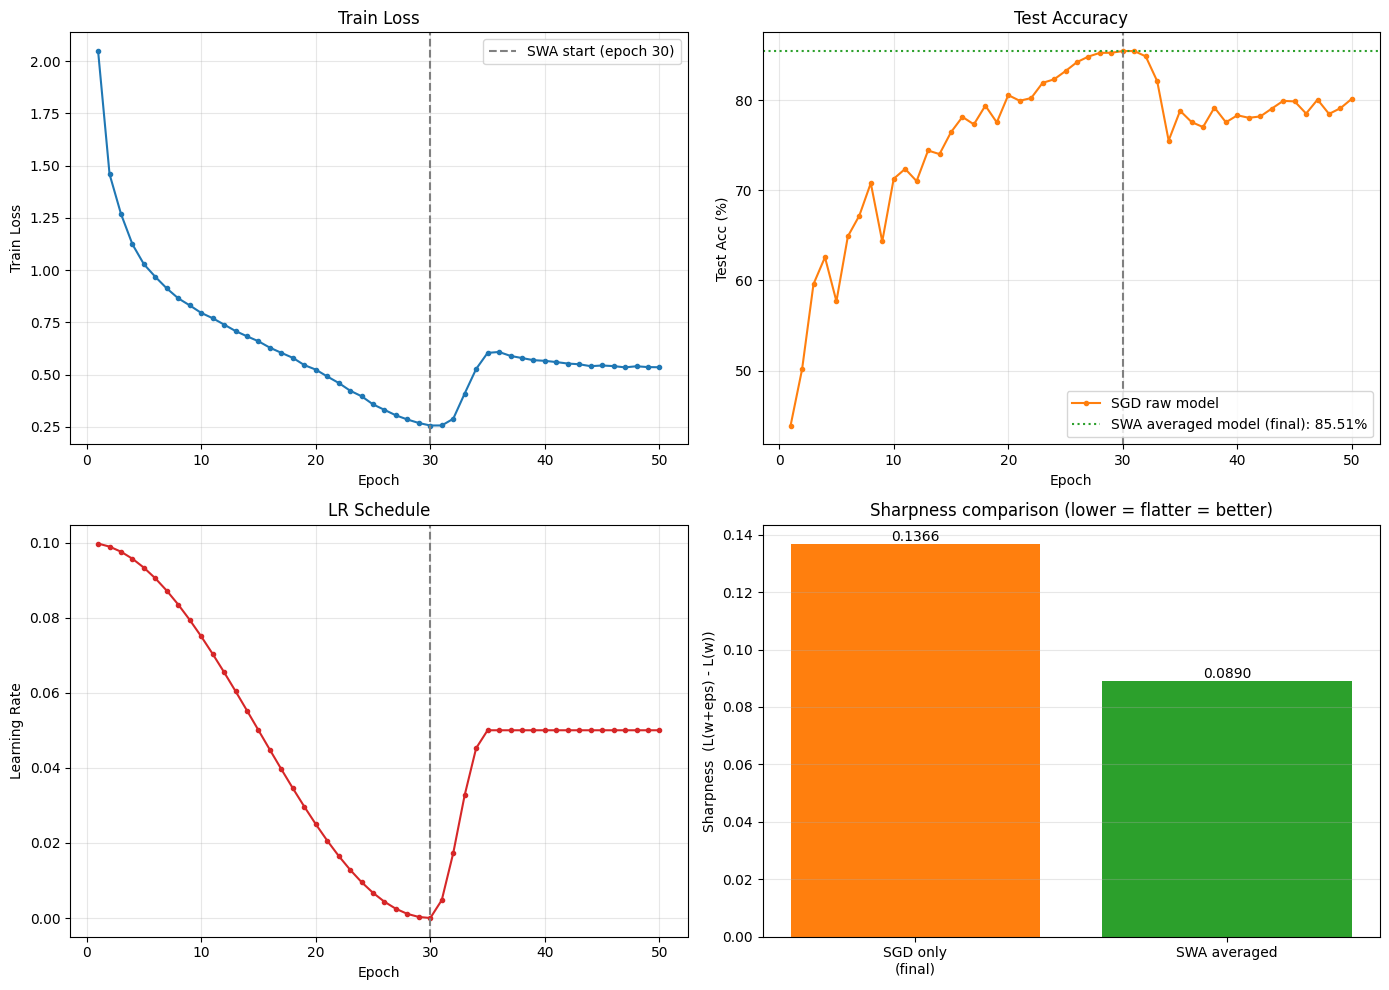


📊 요약
   - 최종 SGD 단독 Test Acc : 80.18% | Sharpness: 0.1366
   - SWA 평균 Test Acc      : 85.51% | Sharpness: 0.0890


In [ ]:
# ==========================================
# 6. 결과 시각화
# ==========================================
# (참고: matplotlib 기본 폰트는 한글 글리프를 지원하지 않아 그래프 안 텍스트가
#  깨져 보일 수 있어서, 그래프 라벨/제목은 영어로 표기합니다. 콘솔 출력은 한글 그대로.)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Train Loss
ax = axes[0, 0]
ax.plot(history['epoch'], history['train_loss'], color='tab:blue', marker='o', markersize=3)
ax.axvline(swa_start, color='gray', linestyle='--', label=f'SWA start (epoch {swa_start})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss'); ax.set_title('Train Loss')
ax.legend(); ax.grid(alpha=0.3)

# 2. Test Accuracy
ax = axes[0, 1]
ax.plot(history['epoch'], history['test_acc_raw'], color='tab:orange', marker='o', markersize=3, label='SGD raw model')
ax.axvline(swa_start, color='gray', linestyle='--')
ax.axhline(swa_test_acc, color='tab:green', linestyle=':', label=f'SWA averaged model (final): {swa_test_acc:.2f}%')
ax.set_xlabel('Epoch'); ax.set_ylabel('Test Acc (%)'); ax.set_title('Test Accuracy')
ax.legend(); ax.grid(alpha=0.3)

# 3. LR Schedule
ax = axes[1, 0]
ax.plot(history['epoch'], history['lr'], color='tab:red', marker='o', markersize=3)
ax.axvline(swa_start, color='gray', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate'); ax.set_title('LR Schedule')
ax.grid(alpha=0.3)

# 4. Sharpness 비교
ax = axes[1, 1]
labels = ['SGD only\n(final)', 'SWA averaged']
values = [sharpness_sgd, sharpness_swa]
colors = ['tab:orange', 'tab:green']
bars = ax.bar(labels, values, color=colors)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f'{v:.4f}', ha='center', va='bottom')
ax.set_ylabel('Sharpness  (L(w+eps) - L(w))')
ax.set_title('Sharpness comparison (lower = flatter = better)')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/swa_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 요약")
print(f"   - 최종 SGD 단독 Test Acc : {final_sgd_acc:.2f}% | Sharpness: {sharpness_sgd:.4f}")
print(f"   - SWA 평균 Test Acc      : {swa_test_acc:.2f}% | Sharpness: {sharpness_swa:.4f}")